**Explanation of parameters**

n_samples = 100 (number of total data points(rows))

n_features = 2 (number of total features (columns))

n_informative = 1 (number of features that are actually useful for determinig the class)

n_redundant = 0 (number of features that are linear combinations of the informative ones)

n_classes = 2 (number of target classes(output labels either 0 or 1))

n_clusters_per_class = 1 (number of sub-clusters within each class)

hypercube = False (controls how informative features are placed)

class_sep = 10 (controls the seperation between classes)

In [49]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=19, hypercube=False,
                            class_sep=10 )

Plot the scatter plot between the two features

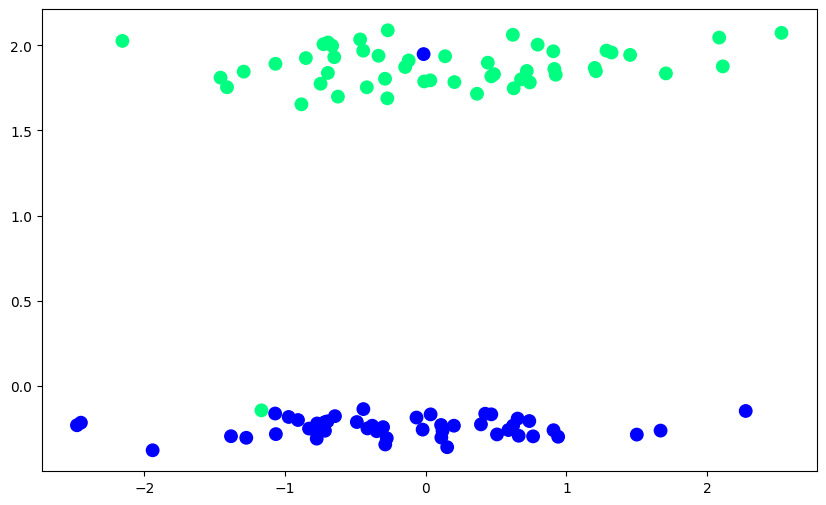

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=80)
plt.show()

In [51]:
def perceptron(X,y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]

In [53]:
def step(z):
    return 1 if z>0 else 0

In [102]:
intercept_, coef_ = perceptron(X, y)

In [103]:
print(intercept_)
print(coef_)

-0.29999999999999993
[-0.00332406  0.37521605]


In [104]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [105]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

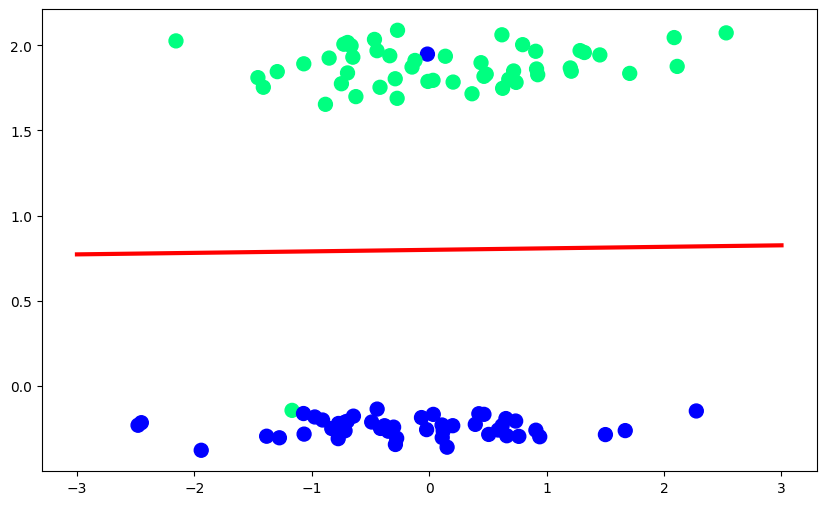

In [110]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color = "red", linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100)
plt.show()

**Annimated**

In [113]:
def Perceptron(X, y):
    m = []
    b = []

    X = np.insert(X, 0, 1, axis=1)
    W = np.ones(X.shape[1])
    lr = 0.1

    for _ in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], W))
        W = W + lr * (y[j] - y_hat) * X[j]

        m.append(-(W[1] / W[2]))
        b.append(-(W[0] / W[2]))
    return m, b

In [114]:
m, b = Perceptron(X, y)

In [125]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [134]:
fig, ax = plt.subplots(figsize = (9, 5))
x_i = np.arange(-3, 3, 0.1)
y_i = x_i * m[0] + b[0]
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s = 100)
line, = ax.plot(x_i, x_i*m[0]+b[0], 'r-', linewidth = 2)

def update(i):
    label = "epoch {0}".format(i+1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    return line, ax

anim = FuncAnimation(fig, update, repeat = True, frames=200, interval = 100)
plt.show()

<IPython.core.display.Javascript object>